In [ ]:
# ==========================================
# 1. SETUP & LIBRARY INSTALLATION
# ==========================================
# We use pmdarima for automatic parameter selection (Auto-ARIMA)
!pip install pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set plot style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# ==========================================
# 2. DATA LOADING & PREPROCESSING
# ==========================================
# Make sure to upload 'BBCA.JK_dataprice.xlsx - Sheet1.csv' to your Colab files
file_path = 'BBCA.JK_dataprice.xlsx'

# Load data
df = pd.read_excel(file_path)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Handle missing values (if any)
df.dropna(inplace=True)

# Display first few rows
print("Data Head:")
print(df.head())

Data Head:
                   Open         High          Low        Close      Volume  \
Date                                                                         
2017-07-31  3435.631645  3477.191706  3431.013861  3454.102783  65311000.0   
2017-08-01  3486.427273  3504.898411  3458.720566  3495.662842  88810000.0   
2017-08-02  3495.662842  3504.898411  3477.191704  3495.662842  62681500.0   
2017-08-03  3518.751793  3518.751793  3426.396103  3463.338379  43917500.0   
2017-08-04  3463.338654  3463.338654  3426.396375  3431.014160  70007000.0   

            Dividends  Stock Splits  
Date                                 
2017-07-31        0.0             0  
2017-08-01        0.0             0  
2017-08-02        0.0             0  
2017-08-03        0.0             0  
2017-08-04        0.0             0  


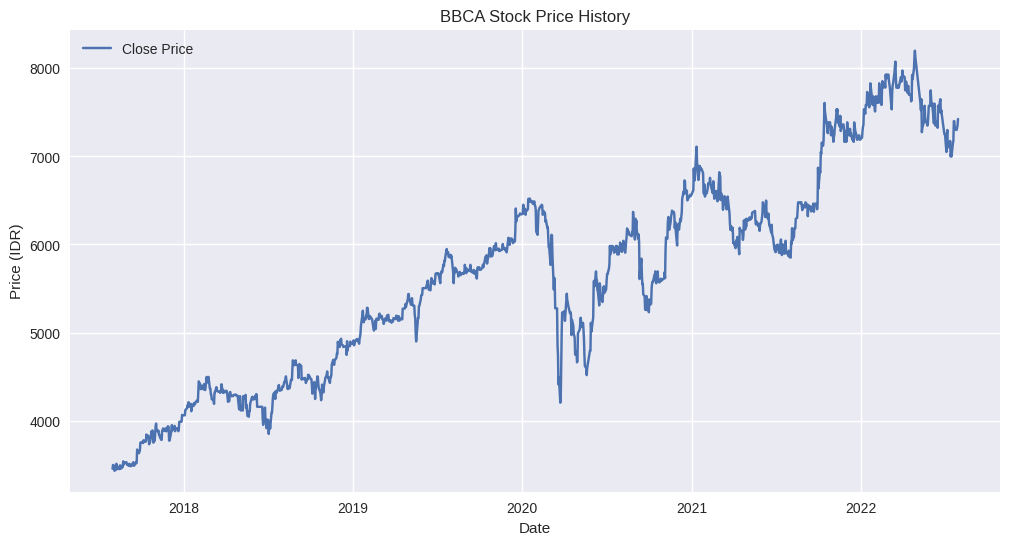


ADF Statistic: -1.335714
p-value: 0.612679
Result: Data is Non-Stationary (Differencing needed)


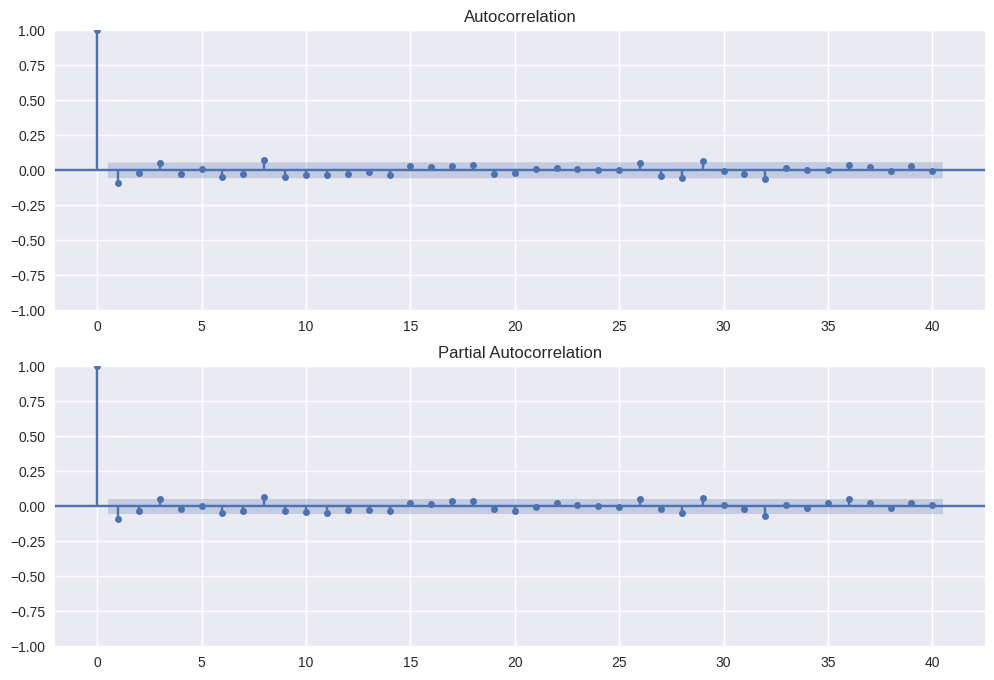

In [ ]:
# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Plot Closing Price
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price')
plt.title('BBCA Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price (IDR)')
plt.legend()
plt.show()

# Check Stationarity (ADF Test)
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('\nADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    if result[1] <= 0.05:
        print("Result: Data is Stationary")
    else:
        print("Result: Data is Non-Stationary (Differencing needed)")

check_stationarity(df['Close'])

# Plot ACF and PACF for differenced data
df['Close_diff'] = df['Close'].diff().dropna()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['Close_diff'].dropna(), ax=ax1, lags=40)
plot_pacf(df['Close_diff'].dropna(), ax=ax2, lags=40)
plt.show()


In [ ]:
# ==========================================
# 4. SARIMAX MODELING
# ==========================================
# Split data into Training and Testing sets (e.g., 90% train, 10% test)
train_size = int(len(df) * 0.9)
train_data = df['Close'][:train_size]
test_data = df['Close'][train_size:]

print(f"\nTraining Samples: {len(train_data)}")
print(f"Testing Samples: {len(test_data)}")

# ---------------------------------------------------------
# STEP A: Find Best Parameters using Auto-ARIMA
# ---------------------------------------------------------
# We use m=5 because stocks typically trade 5 days a week (weekly seasonality)
print("\nRunning Auto-ARIMA to find best parameters...")
auto_model = auto_arima(train_data,
                        start_p=1, start_q=1,
                        max_p=5, max_q=5,
                        m=5,              # Seasonal period (5 days/week)
                        start_P=0, seasonal=True,
                        d=1, D=1,         # Enforce differencing
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print("\nBest Model Parameters found:")
print(auto_model.summary())

# ---------------------------------------------------------
# STEP B: Fit SARIMAX Model
# ---------------------------------------------------------
# Extract best parameters
order = auto_model.order
seasonal_order = auto_model.seasonal_order

# Fit the SARIMAX model
# Note: You can add exogenous variables (like Volume) here using the 'exog' parameter
model = SARIMAX(train_data,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False)


Training Samples: 1129
Testing Samples: 126

Running Auto-ARIMA to find best parameters...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[5]             : AIC=inf, Time=1.26 sec
 ARIMA(0,1,0)(0,1,0)[5]             : AIC=13914.353, Time=0.09 sec
 ARIMA(1,1,0)(1,1,0)[5]             : AIC=13632.076, Time=1.10 sec
 ARIMA(0,1,1)(0,1,1)[5]             : AIC=inf, Time=2.25 sec
 ARIMA(1,1,0)(0,1,0)[5]             : AIC=13909.730, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[5]             : AIC=13459.253, Time=0.65 sec
 ARIMA(1,1,0)(2,1,1)[5]             : AIC=inf, Time=1.92 sec
 ARIMA(1,1,0)(1,1,1)[5]             : AIC=inf, Time=1.02 sec
 ARIMA(0,1,0)(2,1,0)[5]             : AIC=13463.167, Time=0.22 sec
 ARIMA(2,1,0)(2,1,0)[5]             : AIC=13460.565, Time=0.74 sec
 ARIMA(1,1,1)(2,1,0)[5]             : AIC=13462.502, Time=1.62 sec
 ARIMA(0,1,1)(2,1,0)[5]             : AIC=13459.038, Time=0.62 sec
 ARIMA(0,1,1)(1,1,0)[5]             : AIC=13631.880, Time=0.36 sec
 ARIMA(0,1,1)(2,1,

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Model Evaluation:
Root Mean Squared Error (RMSE): 2588.19
Mean Absolute Error (MAE): 2175.40


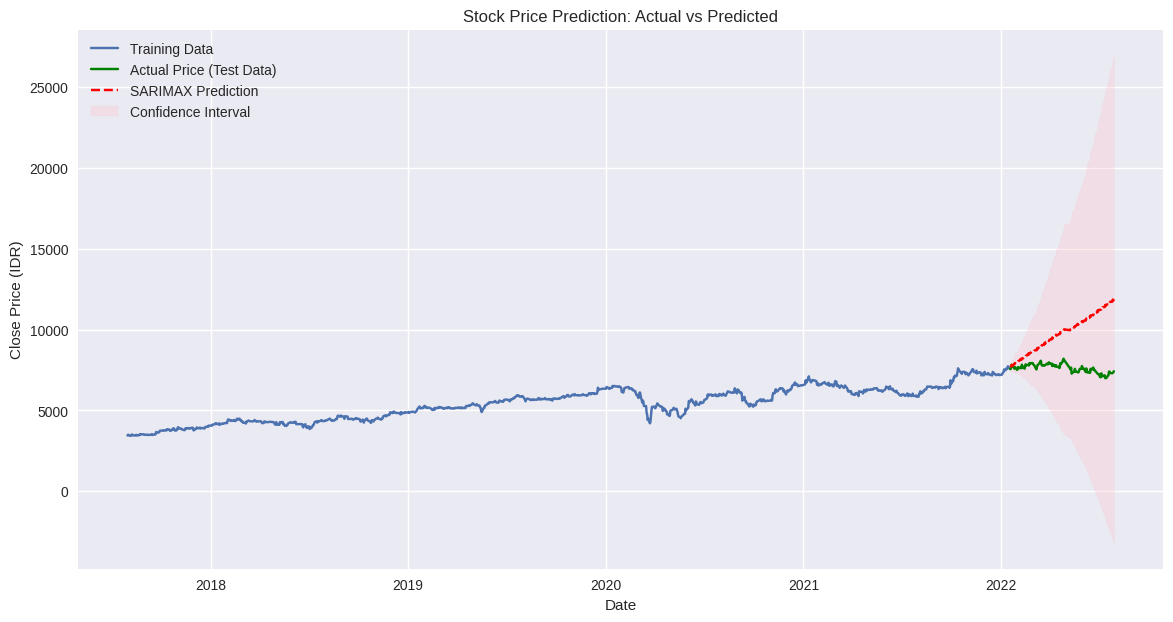

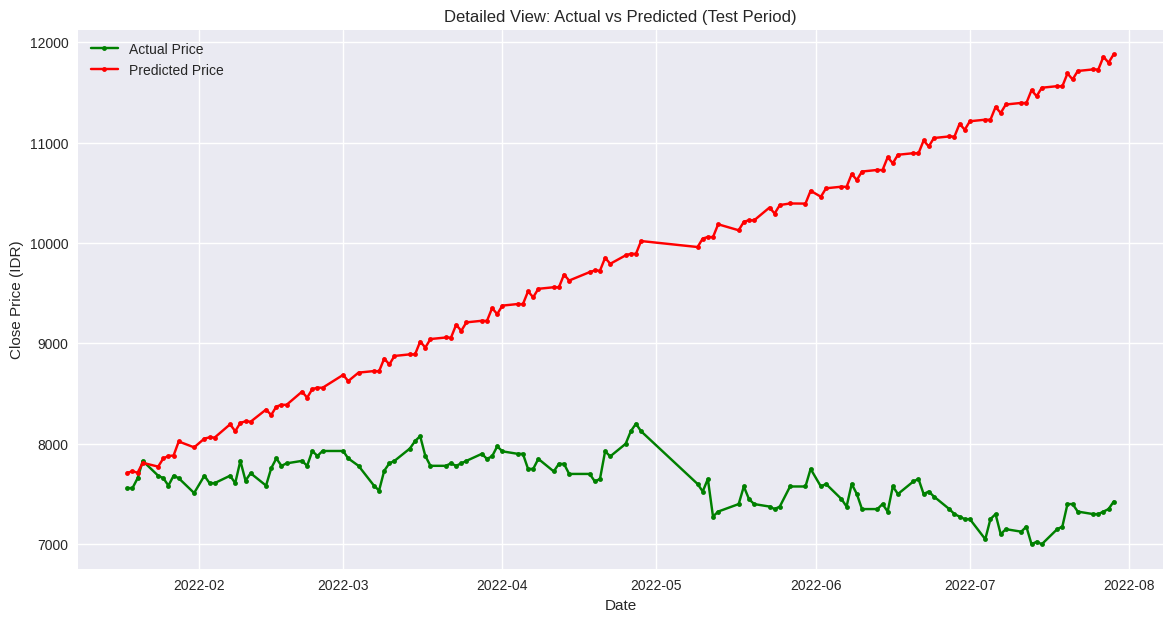

In [ ]:
# ==========================================
# 5. PREDICTION & EVALUATION
# ==========================================
# Forecast on the test set
forecast_result = model_fit.get_forecast(steps=len(test_data))

# Extract predicted mean and confidence intervals
predicted_mean_values = forecast_result.predicted_mean.values
conf_int_values = forecast_result.conf_int().values

# Convert predictions to a pandas Series with correct index
predicted_mean = pd.Series(predicted_mean_values, index=test_data.index)

# Create a DataFrame for confidence intervals with the correct index
conf_int = pd.DataFrame(conf_int_values, index=test_data.index, columns=['lower Close', 'upper Close'])

# Calculate Error Metrics
RMSE = np.sqrt(mean_squared_error(test_data, predicted_mean))
MAE = mean_absolute_error(test_data, predicted_mean)
mean_price = np.mean(y_true)
print(f"\nModel Evaluation:")
MAE_percent  = (MAE / mean_price) * 100
RMSE_percent = (RMSE / mean_price) * 100

print("\n===== XGBoost Performance Metrics (Next-Day Forecast, Last 120 Days) =====")
print(f"MAE  : {MAE:,.2f}   ({MAE_percent:.2f}%)")
print(f"RMSE : {RMSE:,.2f}   ({RMSE_percent:.2f}%)")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Plotting the Results
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Price (Test Data)', color='green')
plt.plot(test_data.index, predicted_mean, label='SARIMAX Prediction', color='red', linestyle='--')
plt.fill_between(test_data.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Zoom into the test period
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data, label='Actual Price', color='green', marker='.')
plt.plot(test_data.index, predicted_mean, label='Predicted Price', color='red', marker='.')
plt.title('Detailed View: Actual vs Predicted (Test Period)')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.legend()
plt.grid(True)
plt.show()